
# CH 5 - 3 : WHAT IS A STATISTICAL HYPOTHESIS?

## Objectif pédagogique

Cette section explique ce qu’est une **hypothèse statistique** dans le cadre EBTA / backtesting.

L’idée centrale est simple :

> Une hypothèse statistique est une conjecture sur la valeur d’un paramètre de population.

En trading, ce paramètre peut être par exemple :

- le rendement moyen futur réel d’une stratégie ;
- le rendement moyen quotidien annualisé ;
- l’espérance d’un edge ;
- la performance attendue de la règle sur une infinité de trades.

Le problème est que ce paramètre est **inconnu**.  
On ne voit jamais directement la vraie performance future d’une stratégie.

On observe seulement un **échantillon** : le backtest.

Le test d’hypothèse sert donc à répondre à une question :

> Le résultat observé dans le backtest est-il suffisamment éloigné de ce qu’on attendrait d’une stratégie sans edge ?



## 1. La logique EBTA

Dans une approche scientifique, on ne part pas de l’idée :

> “Ma stratégie a fait +20 %, donc elle a un edge.”

On part plutôt de l’hypothèse prudente :

$$H_0 : \mu \le 0$$

où :

- $H_0$ est l’hypothèse nulle ;
- $\mu$ est le rendement moyen réel de la stratégie ;
- $\mu \le 0$ signifie que la stratégie n’a pas de valeur prédictive positive.

Autrement dit :

> Par défaut, on suppose que la stratégie ne vaut rien, jusqu’à preuve statistique du contraire.

L’hypothèse alternative est alors :

$$H_A : \mu > 0$$

Cela signifie :

> La stratégie possède une espérance positive réelle.



## 2. Le piège du backtest profitable

Un backtest profitable est une **preuve confirmatoire**, mais ce n’est pas une preuve suffisante.

Une stratégie peut faire +20 % :

- parce qu’elle a un vrai edge ;
- ou parce qu’elle a eu de la chance sur cet échantillon historique.

La question scientifique devient donc :

> Si la stratégie n’avait réellement aucun edge, quelle serait la probabilité d’obtenir un résultat aussi bon que celui observé ?

Cette probabilité est la **p-value**.



## 3. Exemple concret

On va simuler une stratégie de trading avec des rendements quotidiens.

Supposons :

- 252 jours de trading ;
- un rendement moyen observé positif ;
- une volatilité quotidienne réaliste ;
- une hypothèse nulle : rendement moyen réel = 0.

On va calculer :

1. le rendement moyen quotidien observé ;
2. le rendement annualisé ;
3. la statistique de test ;
4. la p-value ;
5. la décision : rejeter ou non $H_0$.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Paramètres de simulation
n_days = 252
daily_vol = 0.01

# Rendement moyen réel simulé de la stratégie
# Ici on met un petit edge positif pour l'exemple.
true_daily_mean = 0.0006

# Simulation des rendements quotidiens de la stratégie
returns = np.random.normal(
    loc=true_daily_mean,
    scale=daily_vol,
    size=n_days
)

df = pd.DataFrame({
    "daily_return": returns
})

df["equity_curve"] = (1 + df["daily_return"]).cumprod()

df.head()


,daily_return,equity_curve
0,0.005567,1.005567
1,-0.000783,1.004780
2,0.007077,1.011891
3,0.015830,1.027909
4,-0.001742,1.026119



## 4. Visualiser le backtest

On trace la courbe d’équité de la stratégie.

Attention : une courbe qui monte ne suffit pas à prouver l’edge.  
Elle montre seulement ce qui s’est passé dans cet échantillon.


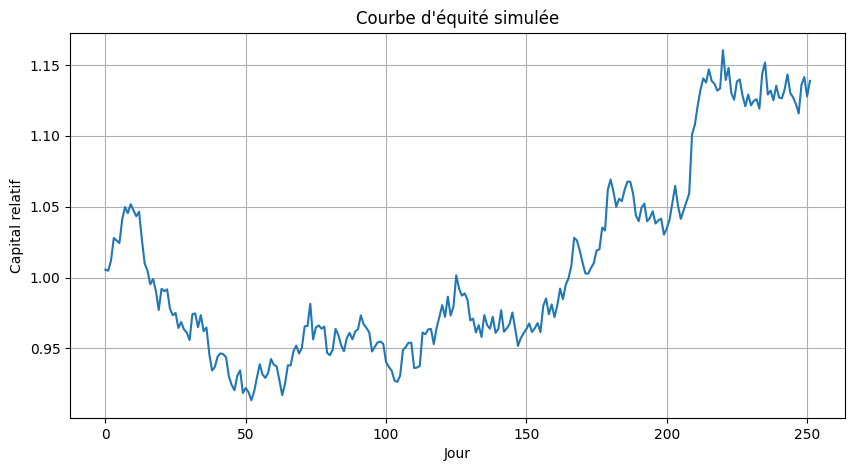

In [2]:

plt.figure(figsize=(10, 5))
plt.plot(df["equity_curve"])
plt.title("Courbe d'équité simulée")
plt.xlabel("Jour")
plt.ylabel("Capital relatif")
plt.grid(True)
plt.show()



## 5. Calcul des statistiques observées

On calcule maintenant les résultats du backtest.

Le rendement moyen quotidien observé est une **statistique d’échantillon**.

Il n’est pas automatiquement égal au vrai paramètre de population.


In [3]:

mean_daily_return = df["daily_return"].mean()
std_daily_return = df["daily_return"].std(ddof=1)
annualized_return = mean_daily_return * 252
annualized_vol = std_daily_return * np.sqrt(252)
sharpe = annualized_return / annualized_vol

summary = pd.DataFrame({
    "Metric": [
        "Mean daily return",
        "Annualized return",
        "Annualized volatility",
        "Sharpe ratio"
    ],
    "Value": [
        mean_daily_return,
        annualized_return,
        annualized_vol,
        sharpe
    ]
})

summary


,Metric,Value
0,Mean daily return,0.000562
1,Annualized return,0.141713
2,Annualized volatility,0.153541
3,Sharpe ratio,0.922964



## 6. Test d’hypothèse

On teste :

$$H_0 : \mu = 0$$

contre :

$$H_A : \mu > 0$$

Dans cet exemple, on utilise un test t unilatéral.

La statistique de test est :

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

où :

- $\bar{x}$ est le rendement moyen observé ;
- $\mu_0$ est le rendement moyen supposé sous $H_0$ ;
- $s$ est l’écart-type des rendements ;
- $n$ est le nombre d’observations.


In [4]:

mu_0 = 0
n = len(df)

t_stat = (mean_daily_return - mu_0) / (std_daily_return / np.sqrt(n))

# Test unilatéral à droite : H_A : mu > 0
p_value = 1 - stats.t.cdf(t_stat, df=n-1)

alpha = 0.05

decision = "Rejeter H0 : evidence statistique d'un edge positif" if p_value < alpha else "Ne pas rejeter H0 : evidence insuffisante"

test_result = pd.DataFrame({
    "Element": [
        "Hypothèse nulle H0",
        "Hypothèse alternative HA",
        "t-statistique",
        "p-value",
        "Seuil alpha",
        "Décision"
    ],
    "Valeur": [
        "mu = 0",
        "mu > 0",
        t_stat,
        p_value,
        alpha,
        decision
    ]
})

test_result


,Element,Valeur
0,Hypothèse nulle H0,mu = 0
1,Hypothèse alternative HA,mu > 0
2,t-statistique,0.922964
3,p-value,0.178456
4,Seuil alpha,0.05
5,Décision,Ne pas rejeter H0 : evidence insuffisante



## 7. Interprétation trading

La p-value répond à cette question :

> Si la stratégie n’avait aucun edge réel, quelle serait la probabilité d’observer un rendement moyen au moins aussi élevé que celui du backtest ?

Si la p-value est faible, par exemple 0.03 :

> Il serait rare d’obtenir un tel résultat si la stratégie était vraiment inutile.

On peut alors rejeter $H_0$ au seuil de 5 %.

Mais attention :

- rejeter $H_0$ ne prouve pas que la stratégie est parfaite ;
- cela indique seulement que l’hypothèse “aucun edge” devient peu crédible ;
- ne pas rejeter $H_0$ ne prouve pas non plus que la stratégie est nulle ;
- cela veut seulement dire que l’échantillon ne fournit pas assez de preuve.



## 8. Visualisation de la zone de rejet

On va visualiser la distribution théorique de la statistique t sous l’hypothèse nulle.

Si la statistique observée tombe très loin dans la queue droite, alors le résultat est considéré comme rare sous $H_0$.


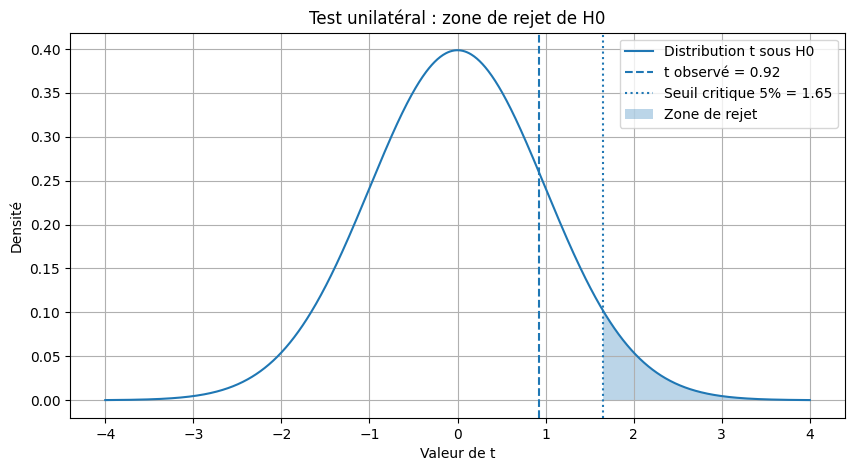

In [5]:

x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=n-1)

critical_value = stats.t.ppf(1 - alpha, df=n-1)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Distribution t sous H0")
plt.axvline(t_stat, linestyle="--", label=f"t observé = {t_stat:.2f}")
plt.axvline(critical_value, linestyle=":", label=f"Seuil critique 5% = {critical_value:.2f}")

# Zone de rejet
x_reject = x[x >= critical_value]
y_reject = stats.t.pdf(x_reject, df=n-1)
plt.fill_between(x_reject, y_reject, alpha=0.3, label="Zone de rejet")

plt.title("Test unilatéral : zone de rejet de H0")
plt.xlabel("Valeur de t")
plt.ylabel("Densité")
plt.legend()
plt.grid(True)
plt.show()



## 9. Ce que cela change dans le trading

Sans hypothèse statistique, le trader regarde seulement :

> “Le backtest est-il profitable ?”

Avec une hypothèse statistique, il demande :

> “Ce profit est-il suffisamment improbable sous l’hypothèse que ma stratégie ne vaut rien ?”

C’est un changement énorme.

On ne juge plus la stratégie à l’intuition.  
On la juge par rapport à une distribution de résultats possibles sous l’hypothèse nulle.



## 10. Exemple avec une stratégie sans edge

Maintenant, on simule une stratégie qui n’a réellement aucun edge :

$$\mu = 0$$

Elle peut quand même produire un backtest positif par hasard.


In [6]:

np.random.seed(1)

no_edge_returns = np.random.normal(
    loc=0,
    scale=daily_vol,
    size=n_days
)

df_no_edge = pd.DataFrame({
    "daily_return": no_edge_returns
})

df_no_edge["equity_curve"] = (1 + df_no_edge["daily_return"]).cumprod()

mean_no_edge = df_no_edge["daily_return"].mean()
std_no_edge = df_no_edge["daily_return"].std(ddof=1)
ann_return_no_edge = mean_no_edge * 252

t_no_edge = mean_no_edge / (std_no_edge / np.sqrt(n_days))
p_no_edge = 1 - stats.t.cdf(t_no_edge, df=n_days-1)

pd.DataFrame({
    "Metric": [
        "Mean daily return",
        "Annualized return",
        "t-statistique",
        "p-value"
    ],
    "Value": [
        mean_no_edge,
        ann_return_no_edge,
        t_no_edge,
        p_no_edge
    ]
})


,Metric,Value
0,Mean daily return,0.000734
1,Annualized return,0.185052
2,t-statistique,1.226145
3,p-value,0.110647


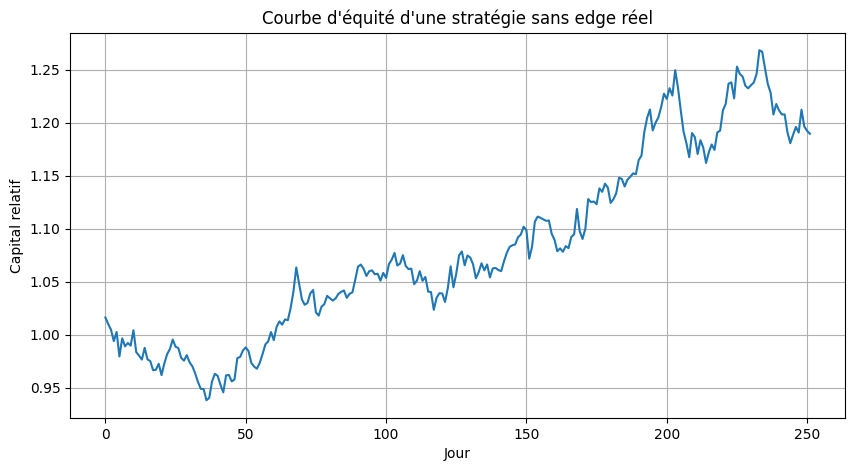

In [7]:

plt.figure(figsize=(10, 5))
plt.plot(df_no_edge["equity_curve"])
plt.title("Courbe d'équité d'une stratégie sans edge réel")
plt.xlabel("Jour")
plt.ylabel("Capital relatif")
plt.grid(True)
plt.show()



## 11. Lecture EBTA

Une stratégie sans edge peut parfois avoir une belle courbe d’équité sur un échantillon.

C’est pour cela que le raisonnement EBTA impose :

1. formuler $H_0$ avant de juger ;
2. mesurer la distance entre le backtest et $H_0$ ;
3. convertir cette distance en p-value ;
4. décider selon un seuil fixé à l’avance.

Le but n’est pas de chercher des histoires qui justifient la courbe.

Le but est de savoir si la courbe est suffisamment exceptionnelle pour remettre en question l’hypothèse de zéro talent.



## 12. À retenir absolument

Une hypothèse statistique n’est pas une opinion vague.

C’est une affirmation précise sur un paramètre inconnu.

En trading :

- le paramètre est la vraie performance attendue de la stratégie ;
- le backtest est seulement un échantillon ;
- $H_0$ suppose généralement que l’edge est nul ou négatif ;
- la p-value mesure la rareté du résultat observé si $H_0$ était vraie ;
- on ne prouve jamais définitivement qu’une stratégie est bonne ;
- on peut seulement rejeter ou ne pas rejeter l’hypothèse qu’elle ne vaut rien.

## Formule mentale

> Un backtest profitable dit : “j’ai gagné dans le passé.”  
> Un test d’hypothèse demande : “est-ce que ce gain est trop rare pour être attribué facilement à la chance ?”



## 13. Mini check-list pratique pour tes backtests

Avant de conclure qu’une stratégie a un edge :

1. Définis clairement $H_0$ : rendement attendu $\le 0$.
2. Définis $H_A$ : rendement attendu $> 0$.
3. Calcule les rendements de la règle.
4. Si besoin, travaille sur données dé-tendancées.
5. Calcule la statistique observée.
6. Estime la distribution d’échantillonnage.
7. Calcule la p-value.
8. Compare au seuil choisi avant le test.
9. Ne confonds jamais profit observé et edge prouvé.
10. Méfie-toi encore plus si plusieurs stratégies ont été testées.
